# CNN–RNN Pipeline for Reading Spatial Sequences in Images

This notebook is a **teaching template** that demonstrates a clean end-to-end PyTorch workflow for a hybrid model:

- A **CNN** extracts local visual features from an image
- An **RNN (GRU/LSTM)** reads those features **left-to-right** as a sequence
- The model predicts **which vertical column bin** contains a bright dot

Key goals:
- Understand how to turn a 2D feature map `(B, C, H, W)` into a sequence `(B, T, D)`
- See what a CNN–RNN model outputs **at each stage** (with shapes and examples)
- Train with a small Trainer that saves **last** and **best** checkpoints
- Visualize predictions with **vertical grid lines** so column bins are obvious

> This is not about achieving the best score.  
> It is about understanding the mechanics and writing clean, inspectable code.


## 1) Setup (imports, device, reproducibility)

In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

torch.set_printoptions(precision=4, sci_mode=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Device: cpu


## 2) Problem definition

We generate images of size `H×W` (RGB).  
Each image contains a small bright dot located in exactly one of `N_BINS` vertical columns.

- The **label** is the index of the column bin: `0, 1, ..., N_BINS-1`
- The model must predict the correct bin.

Why this is a good CNN–RNN example:
- The dot is a **local** feature (CNN is good at detecting local patterns)
- The bin index is naturally linked to **left-to-right position** (RNN reads a sequence along width)


## 3) On-the-fly dataset with deterministic samples per index

In [3]:
@dataclass
class DotSeqConfig:
    height: int = 64
    width: int = 64
    n_bins: int = 8
    dot_radius: int = 2
    background_noise_std: float = 0.03
    dot_intensity: float = 1.0  # 1.0 = white dot in [0,1]
    base_seed: int = 123  # used to make samples deterministic per index

class DotInColumnDataset(Dataset):
    """Generate RGB images on the fly, but deterministically per index.

    Deterministic per index means:
    - index i always produces the same image/label
    - train/val/test splits are reproducible
    """
    def __init__(self, length: int, cfg: DotSeqConfig):
        self.length = length
        self.cfg = cfg

    def __len__(self) -> int:
        return self.length

    def _rng_for_index(self, idx: int) -> np.random.Generator:
        # Make a per-index RNG so sample idx is stable across runs
        return np.random.default_rng(self.cfg.base_seed + idx)

    def __getitem__(self, idx: int):
        rng = self._rng_for_index(idx)
        H, W = self.cfg.height, self.cfg.width
        n_bins = self.cfg.n_bins

        # Choose which vertical bin contains the dot
        label = int(rng.integers(0, n_bins))

        # Compute x-range for that bin
        bin_w = W / n_bins
        x0 = int(label * bin_w)
        x1 = int((label + 1) * bin_w) - 1

        # Choose a dot center inside the bin and away from borders
        r = self.cfg.dot_radius
        cx = int(rng.integers(max(r, x0), min(x1, W - r - 1) + 1))
        cy = int(rng.integers(r, H - r - 1))

        # Background: noise around 0 (then clipped to [0,1])
        img = rng.normal(loc=0.0, scale=self.cfg.background_noise_std, size=(H, W, 3)).astype(np.float32)
        img = np.clip(img, 0.0, 1.0)

        # Draw a filled disk (simple circle) for the dot
        yy, xx = np.ogrid[:H, :W]
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[mask] = self.cfg.dot_intensity

        # Convert to torch tensor: (C,H,W), float32 in [0,1]
        x = torch.from_numpy(img).permute(2, 0, 1).contiguous()
        y = torch.tensor(label, dtype=torch.long)
        return x, y


## 4) Train/validation/test split (stratified)

Even though the dataset is generated on the fly, each index has a fixed label.
So we can:
- generate labels for all indices once,
- do a stratified split over indices,
- and then use `Subset`.

This gives stable, reproducible splits.


In [7]:
from sklearn.model_selection import train_test_split

cfg = DotSeqConfig(height=64, width=64, n_bins=8, dot_radius=2, background_noise_std=0.03, base_seed=123)

N = 6000
full_ds = DotInColumnDataset(length=N, cfg=cfg)

# Collect labels for stratification
labels = np.array([int(full_ds[i][1].item()) for i in range(N)])
indices = np.arange(N)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=labels)
temp_labels = labels[temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=temp_labels)

print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

# Quick distribution check
def dist(name, idx):
    c = np.bincount(labels[idx], minlength=cfg.n_bins)
    print(name, c, "sum=", c.sum())
dist("train", train_idx)
dist("val  ", val_idx)
dist("test ", test_idx)


Split sizes: 4200 900 900
train [489 513 564 498 527 564 512 533] sum= 4200
val   [105 110 121 107 113 121 109 114] sum= 900
test  [105 110 121 106 112 121 110 115] sum= 900


## 5) DataLoaders

Notes:
- `shuffle=True` for training
- `shuffle=False` for validation and test
- Start with `num_workers=0` for reliability; increase later if needed.


In [8]:
batch_size = 64

train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(Subset(full_ds, val_idx),   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(Subset(full_ds, test_idx),  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, "Batch y:", yb.shape)


Batch x: torch.Size([64, 3, 64, 64]) Batch y: torch.Size([64])


## 6) Visualization helper with vertical bin lines

We want the bin boundaries to be obvious.
We will draw vertical lines at bin borders and annotate `true` and `pred`.


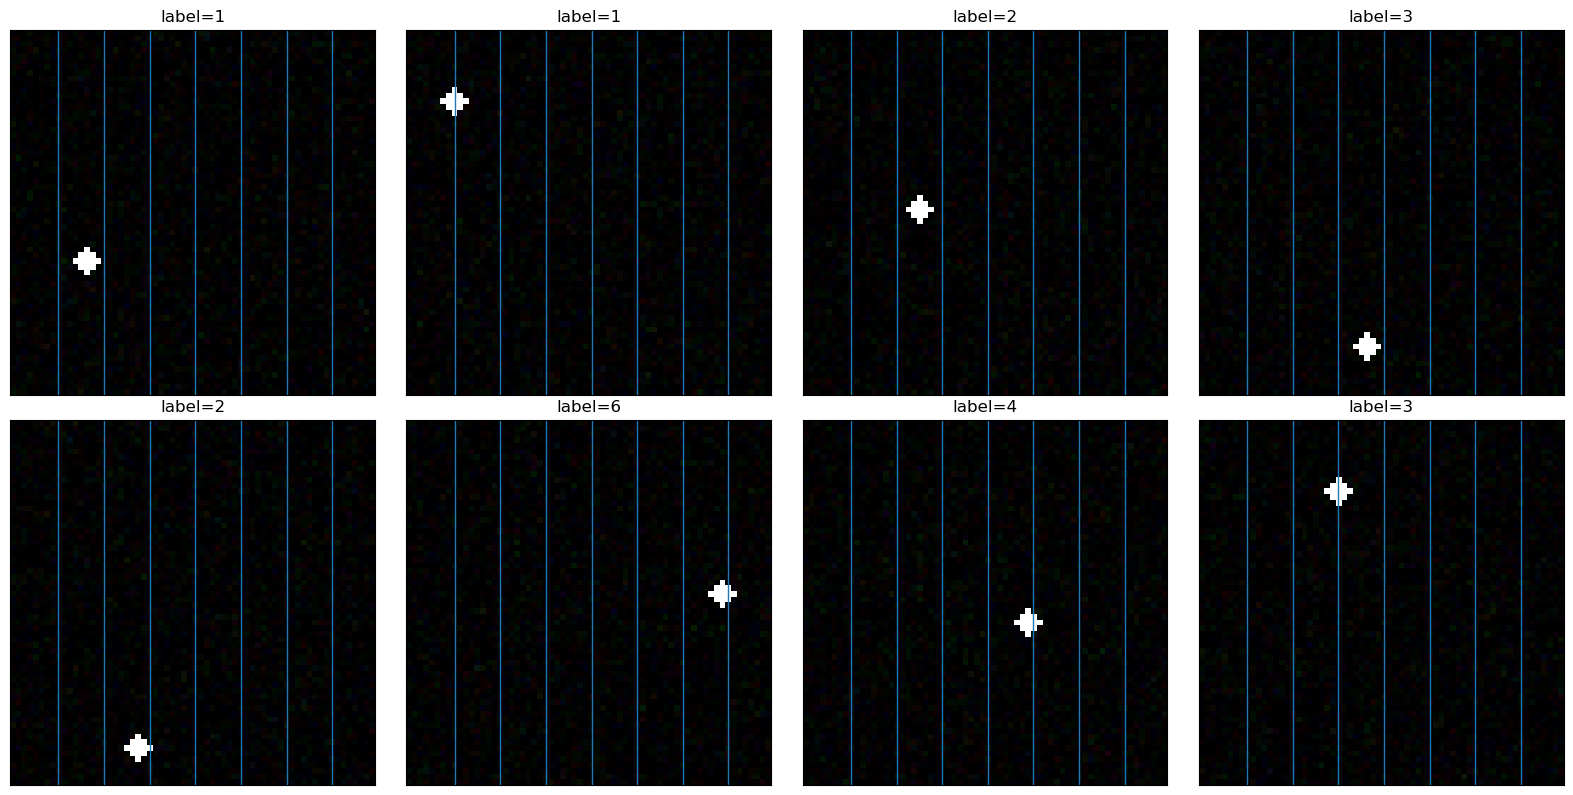

In [9]:
def show_with_bins(img_tensor_chw: torch.Tensor, n_bins: int, title: str = "", ax=None):
    """img_tensor_chw: (3,H,W) in [0,1]"""
    img = img_tensor_chw.permute(1,2,0).detach().cpu().numpy()
    H, W, _ = img.shape

    if ax is None:
        ax = plt.gca()

    ax.imshow(img)
    # draw vertical bin borders
    for k in range(1, n_bins):
        x = k * W / n_bins
        ax.axvline(x=x, linewidth=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

def show_samples(loader, n=8, ncols=4):
    xb, yb = next(iter(loader))
    n = min(n, xb.size(0))
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i+1)
        show_with_bins(xb[i], cfg.n_bins, title=f"label={int(yb[i])}", ax=ax)
    plt.tight_layout()
    plt.show()

show_samples(train_loader, n=8, ncols=4)


## 7) A baseline CNN–RNN model

### Key idea: convert feature map to sequence

A CNN produces a feature map:
- `feat`: `(B, C, H', W')`

To read left-to-right, we turn it into a sequence:
1. Average over height `H'`: `(B, C, W')`
2. Transpose to `(B, W', C)` so time dimension is width

Then an RNN reads the sequence:
- GRU/LSTM output: `(B, W', hidden_size)`

We classify using the last time step output.


In [10]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_ch: int = 3, feat_ch: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32
            nn.Conv2d(16, feat_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16
        )

    def forward(self, x):
        return self.net(x)  # (B, feat_ch, 16, 16)

class CNNRNNClassifier(nn.Module):
    def __init__(self, n_bins: int, rnn_hidden: int = 64, feat_ch: int = 32, rnn_type: str = "gru"):
        super().__init__()
        self.cnn = CNNFeatureExtractor(in_ch=3, feat_ch=feat_ch)
        self.rnn_type = rnn_type.lower()

        # The RNN reads sequences of length W' with feature dimension feat_ch
        if self.rnn_type == "gru":
            self.rnn = nn.GRU(input_size=feat_ch, hidden_size=rnn_hidden, batch_first=True)
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(input_size=feat_ch, hidden_size=rnn_hidden, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'gru' or 'lstm'")

        self.head = nn.Linear(rnn_hidden, n_bins)

    def forward(self, x, return_intermediates: bool = False):
        # 1) CNN features
        feat = self.cnn(x)  # (B, C, H', W')

        # 2) Convert to sequence along width:
        #    average over height -> (B, C, W')
        seq = feat.mean(dim=2)

        #    transpose -> (B, W', C) because batch_first=True expects (B,T,D)
        seq = seq.transpose(1, 2)

        # 3) RNN over width sequence
        out, state = self.rnn(seq)  # out: (B, W', rnn_hidden)

        # 4) Use the last time step
        last = out[:, -1, :]        # (B, rnn_hidden)
        logits = self.head(last)    # (B, n_bins)

        if return_intermediates:
            return logits, feat, seq, out, last
        return logits

model = CNNRNNClassifier(n_bins=cfg.n_bins, rnn_hidden=64, feat_ch=32, rnn_type="gru").to(device)

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    logits, feat, seq, rnn_out, last = model(xb, return_intermediates=True)

print("Input:", xb.shape)
print("CNN feat:", feat.shape, "   (B,C,H',W')")
print("Seq:", seq.shape, "       (B,T=W',D=C)")
print("RNN out:", rnn_out.shape, " (B,T,H_rnn)")
print("Last:", last.shape, "     (B,H_rnn)")
print("Logits:", logits.shape, "   (B,n_bins)")


Input: torch.Size([64, 3, 64, 64])
CNN feat: torch.Size([64, 32, 16, 16])    (B,C,H',W')
Seq: torch.Size([64, 16, 32])        (B,T=W',D=C)
RNN out: torch.Size([64, 16, 64])  (B,T,H_rnn)
Last: torch.Size([64, 64])      (B,H_rnn)
Logits: torch.Size([64, 8])    (B,n_bins)


## 8) Trainer: save last and best checkpoints, plus metrics

We will:
- train for a few epochs,
- track validation accuracy,
- save:
  - `checkpoints/last.pt` every epoch (overwrite)
  - `checkpoints/best.pt` whenever validation improves

We also store:
- `history` (loss/accuracy curves),
- and evaluate both best and last at the end.


In [11]:
from dataclasses import dataclass
from typing import Dict, Optional

@dataclass
class EpochStats:
    loss: float
    acc: float

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

class Trainer:
    def __init__(self, model: nn.Module, optimizer, criterion, device: torch.device, out_dir: Path):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.out_dir = Path(out_dir)

        self.ckpt_dir = self.out_dir / "checkpoints"
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        self.history: Dict[str, list] = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
        }

        self.best_val_acc = -1.0

    def train_one_epoch(self, loader: DataLoader) -> EpochStats:
        self.model.train()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        for xb, yb in loader:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            logits = self.model(xb)
            loss = self.criterion(logits, yb)

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            total_acc += accuracy_from_logits(logits, yb)
            n_batches += 1

        return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches)

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> EpochStats:
        self.model.eval()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        for xb, yb in loader:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            logits = self.model(xb)
            loss = self.criterion(logits, yb)

            total_loss += loss.item()
            total_acc += accuracy_from_logits(logits, yb)
            n_batches += 1

        return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches)

    def save(self, path: Path):
        torch.save(self.model.state_dict(), path)

    def load(self, path: Path):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, epochs: int = 8):
        for ep in range(1, epochs + 1):
            tr = self.train_one_epoch(train_loader)
            va = self.evaluate(val_loader)

            self.history["train_loss"].append(tr.loss)
            self.history["train_acc"].append(tr.acc)
            self.history["val_loss"].append(va.loss)
            self.history["val_acc"].append(va.acc)

            # Save last every epoch
            self.save(self.ckpt_dir / "last.pt")

            # Save best if improved
            if va.acc > self.best_val_acc:
                self.best_val_acc = va.acc
                self.save(self.ckpt_dir / "best.pt")

            print(f"Epoch {ep:02d} | train loss {tr.loss:.4f}, acc {tr.acc:.3f} | val loss {va.loss:.4f}, acc {va.acc:.3f} | best val acc {self.best_val_acc:.3f}")


## 9) Train and plot curves

Epoch 01 | train loss 1.8261, acc 0.291 | val loss 0.9915, acc 0.690 | best val acc 0.690
Epoch 02 | train loss 0.5477, acc 0.902 | val loss 0.2925, acc 0.985 | best val acc 0.985
Epoch 03 | train loss 0.1940, acc 0.995 | val loss 0.1157, acc 1.000 | best val acc 1.000
Epoch 04 | train loss 0.0839, acc 1.000 | val loss 0.0563, acc 1.000 | best val acc 1.000
Epoch 05 | train loss 0.0442, acc 1.000 | val loss 0.0331, acc 1.000 | best val acc 1.000
Epoch 06 | train loss 0.0278, acc 1.000 | val loss 0.0221, acc 1.000 | best val acc 1.000
Epoch 07 | train loss 0.0188, acc 1.000 | val loss 0.0155, acc 1.000 | best val acc 1.000
Epoch 08 | train loss 0.0136, acc 1.000 | val loss 0.0119, acc 1.000 | best val acc 1.000


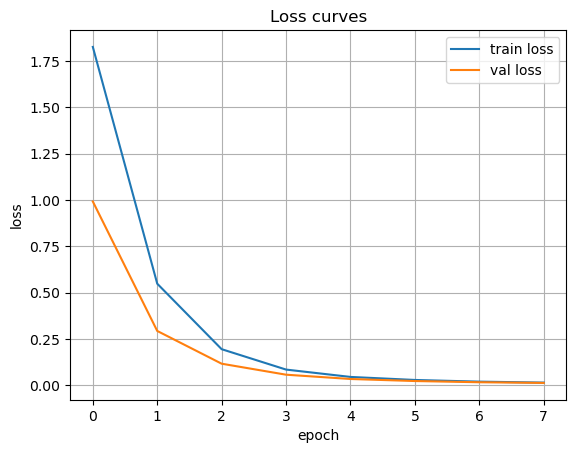

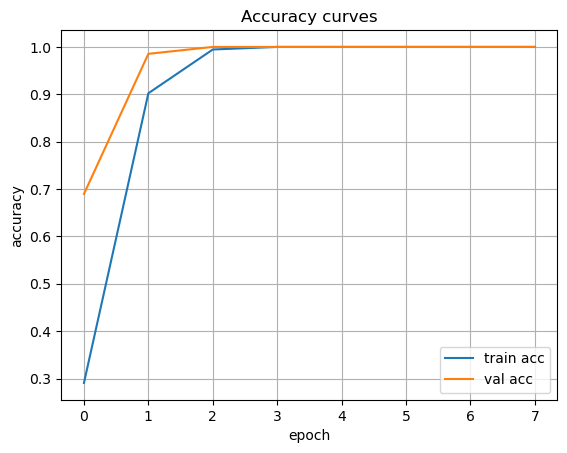

In [12]:
out_dir = Path("cnn_rnn_dot_experiment")
out_dir.mkdir(parents=True, exist_ok=True)

model = CNNRNNClassifier(n_bins=cfg.n_bins, rnn_hidden=64, feat_ch=32, rnn_type="gru").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, device=device, out_dir=out_dir)
trainer.fit(train_loader, val_loader, epochs=8)

history = trainer.history

plt.figure()
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss curves")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.title("Accuracy curves")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 10) Evaluate best and last checkpoints on the test set

We load each checkpoint, evaluate on the same test loader, and report accuracy.


In [13]:
def evaluate_checkpoint(ckpt_path: Path) -> EpochStats:
    trainer.load(ckpt_path)
    return trainer.evaluate(test_loader)

best_stats = evaluate_checkpoint(trainer.ckpt_dir / "best.pt")
last_stats = evaluate_checkpoint(trainer.ckpt_dir / "last.pt")

print("Test results (best): loss=", round(best_stats.loss, 4), "acc=", round(best_stats.acc, 3))
print("Test results (last): loss=", round(last_stats.loss, 4), "acc=", round(last_stats.acc, 3))


C:\Users\jom_j\AppData\Local\Temp\ipykernel_8780\1383517454.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(path, map_location=sel

Test results (best): loss= 0.1207 acc= 1.0
Test results (last): loss= 0.0125 acc= 1.0


## 11) Visualize predictions with bin lines

We show images with:
- vertical bin boundaries
- `true` and `pred` labels

We do this for both:
- best checkpoint
- last checkpoint


Best checkpoint predictions


C:\Users\jom_j\AppData\Local\Temp\ipykernel_8780\1383517454.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(path, map_location=sel

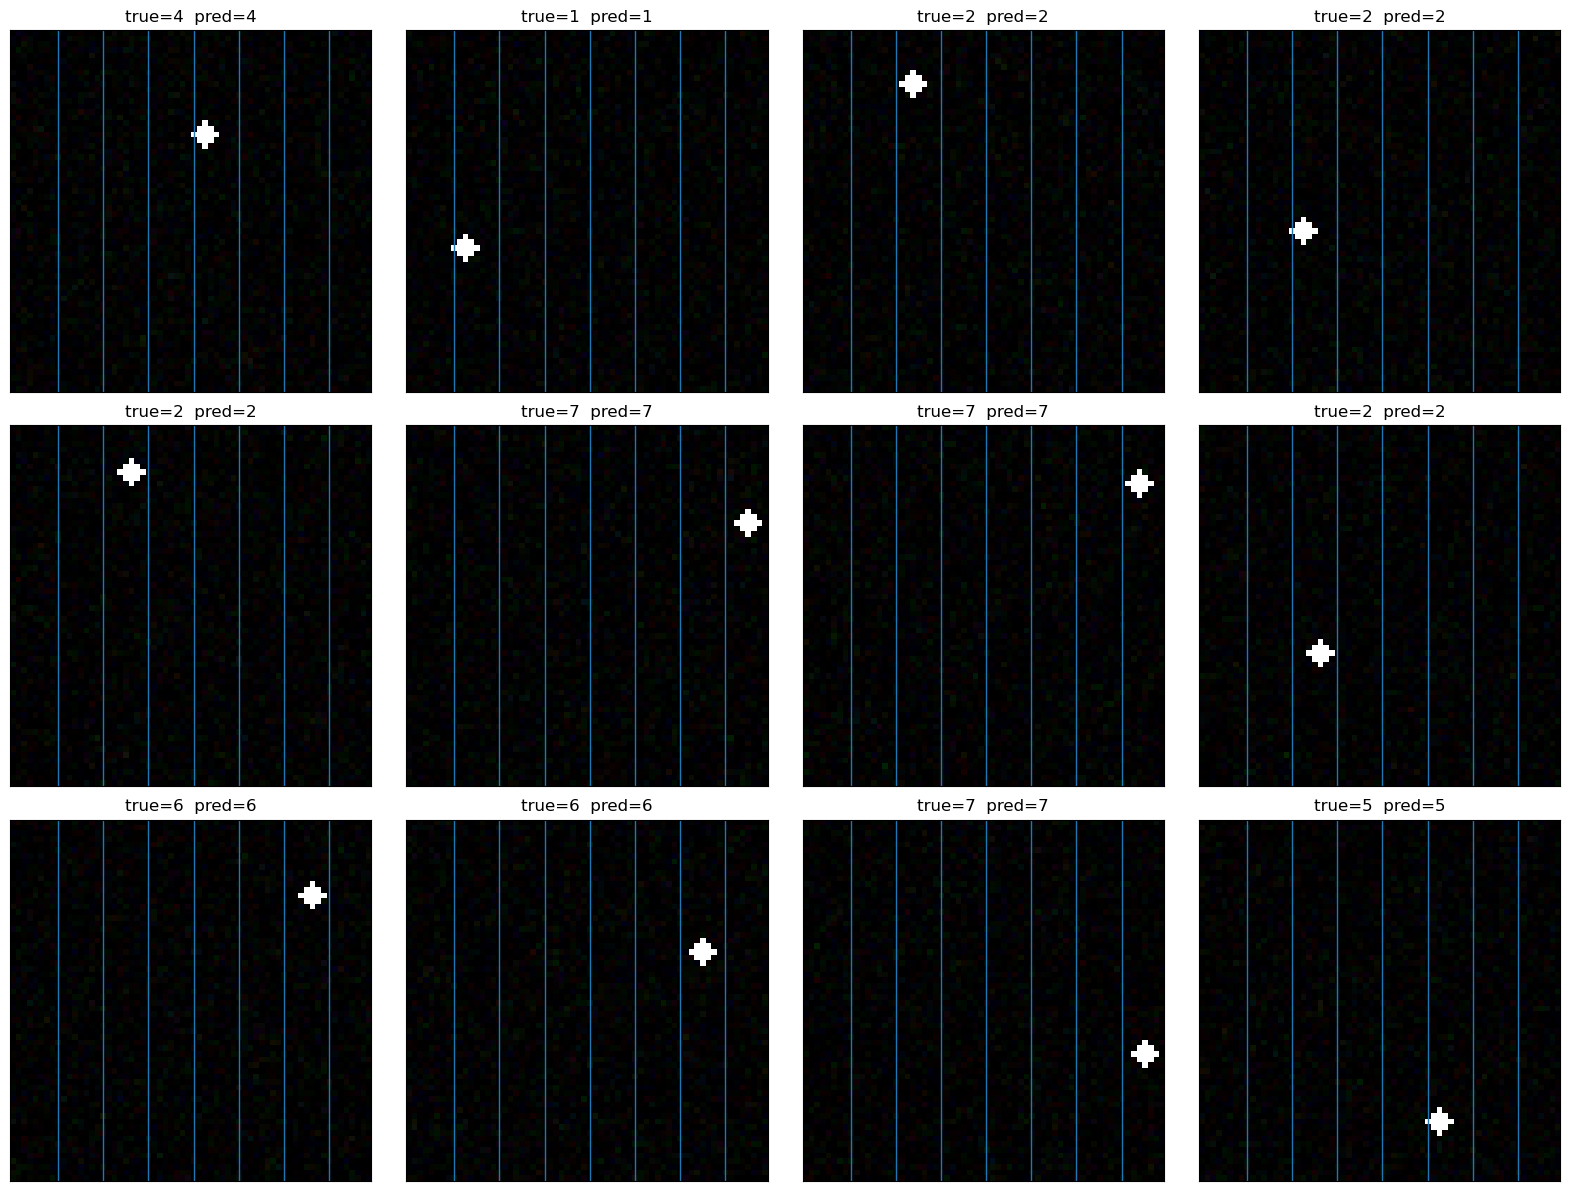

Last checkpoint predictions


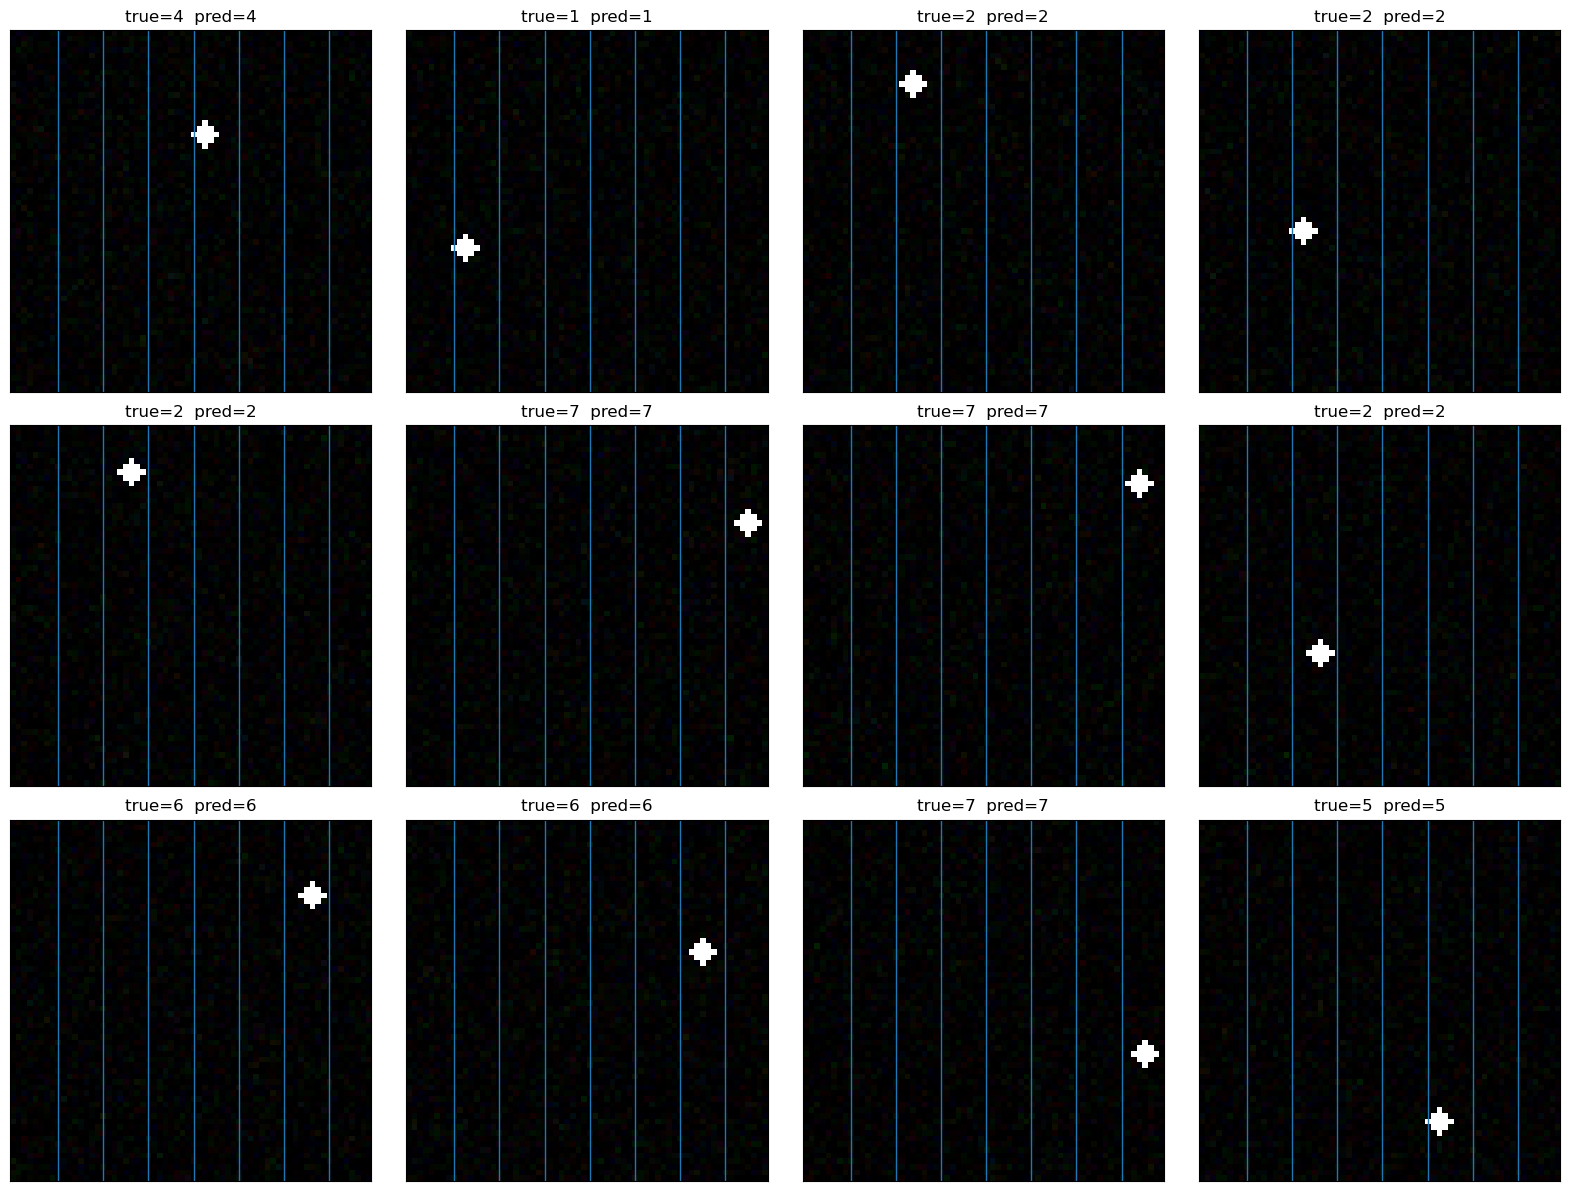

In [14]:
@torch.no_grad()
def show_predictions(ckpt_path: Path, n: int = 12, ncols: int = 4):
    trainer.load(ckpt_path)
    trainer.model.eval()

    xb, yb = next(iter(test_loader))
    xb = xb.to(device)
    yb = yb.to(device)

    logits = trainer.model(xb)
    preds = logits.argmax(dim=1)

    n = min(n, xb.size(0))
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i in range(n):
        ax = plt.subplot(nrows, ncols, i+1)
        title = f"true={int(yb[i])}  pred={int(preds[i])}"
        show_with_bins(xb[i].cpu(), cfg.n_bins, title=title, ax=ax)

    plt.tight_layout()
    plt.show()

print("Best checkpoint predictions")
show_predictions(trainer.ckpt_dir / "best.pt", n=12, ncols=4)

print("Last checkpoint predictions")
show_predictions(trainer.ckpt_dir / "last.pt", n=12, ncols=4)


## 12) Suggestions for experiments

Try modifying the baseline and observe how curves and predictions change:

1. **CNN depth**
   - Add another Conv+ReLU block
   - Change feature channels (e.g., 32 → 64)

2. **RNN choice**
   - Replace GRU with LSTM
   - Make the RNN bidirectional (`bidirectional=True`) and update the classifier head

3. **Sequence construction**
   - Instead of `mean over height`, try `max over height`
   - Try a different CNN downsampling so the sequence length `W'` changes

4. **Regularization**
   - Add dropout in the RNN (`dropout=` for multi-layer RNN)
   - Add weight decay in Adam

5. **Harder dataset**
   - Increase noise
   - Reduce dot intensity
   - Make the dot smaller
